# 逆フーリエ変換によるスペクトル可視化

NIRスペクトル（波数領域の吸光度, 約4000〜9994 cm⁻¹）を**逆フーリエ変換 (`np.fft.ifft`)** して
インターフェログラム的な表現に戻し、樹種ごとに可視化する。

- **学習データ**: 各曲線を目的変数 **含水率** で配色（viridis）
- **テストデータ**: 含水率が無いため単色（樹種ごとに分けて表示）
- 学習・テストともに **樹種ごと** にサブプロットを分けて描画する

※ 学習13樹種・テスト6樹種で樹種集合は重複しない。

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

# 日本語フォント（macOS）
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False

META = ['sample number', 'species number', '樹種', '含水率']
train = pd.read_csv('../data/train_clean.csv', encoding='cp932')
test = pd.read_csv('../data/test.csv', encoding='cp932')

wn_cols = [c for c in train.columns if c not in META]  # 波数カラム
wavenumbers = np.array([float(c) for c in wn_cols])
print('波数点数:', len(wn_cols), '範囲:', wavenumbers.min(), '-', wavenumbers.max())
print('train', train.shape, '/ test', test.shape)

波数点数: 1555 範囲: 3999.82139 - 9993.76781
train (1270, 1559) / test (550, 1558)


In [2]:
def to_interferogram(df):
    """波数領域スペクトルを逆FFTし、中心化した実部インターフェログラムを返す"""
    spec = df[wn_cols].to_numpy(dtype=float)        # (n_samples, n_wn)
    ifg = np.fft.fftshift(np.fft.ifft(spec, axis=1).real, axes=1)
    return ifg

train_ifg = to_interferogram(train)
test_ifg = to_interferogram(test)
N = train_ifg.shape[1]
x = np.arange(N) - N // 2                            # 中心(センターバースト)を0とする点番号
print('interferogram shape:', train_ifg.shape, test_ifg.shape)

interferogram shape: (1270, 1555) (550, 1555)


In [3]:
def plot_by_species(df, ifg, title, color_col=None, ncols=4, cmap='viridis',
                    line_color='steelblue', center_guard=5):
    """樹種ごとにサブプロットを分けてインターフェログラムを描画。
    color_col があれば各曲線をその値で配色し、共通カラーバーを付ける。"""
    species = df['樹種'].value_counts().index.tolist()
    nrows = int(np.ceil(len(species) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
    axes = axes.ravel()

    sm = None
    if color_col is not None:
        norm = mpl.colors.Normalize(df[color_col].min(), df[color_col].max())
        sm = ScalarMappable(norm=norm, cmap=cmap)

    sp_arr = df['樹種'].to_numpy()
    guard = np.abs(x) > center_guard  # センターバースト除外（縦軸スケール用）
    for ax, sp in zip(axes, species):
        idx = np.where(sp_arr == sp)[0]
        for i in idx:
            c = sm.to_rgba(df[color_col].to_numpy()[i]) if sm is not None else line_color
            ax.plot(x, ifg[i], color=c, lw=0.4, alpha=0.5)
        ax.set_title(f'{sp} (n={len(idx)})')
        ax.set_xlabel('インターフェログラム点 (中心=0)')
        ax.set_ylabel('振幅(実部)')
        # センターバースト以外が見えるよう縦軸を頑健に自動調整
        lim = np.percentile(np.abs(ifg[idx][:, guard]), 99.5)
        ax.set_ylim(-lim, lim)
    for ax in axes[len(species):]:
        ax.axis('off')

    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if sm is not None:
        fig.colorbar(sm, ax=axes.tolist(), label=color_col, shrink=0.6, pad=0.01)
    plt.show()

## 学習データ（樹種ごと・含水率で配色）

各曲線 = 1サンプルの逆FFTインターフェログラム。色 = 含水率（明るいほど高含水率）。
中心の巨大なセンターバーストは縦軸スケールから除外し、含水率差が現れる裾の構造を見やすくしている。

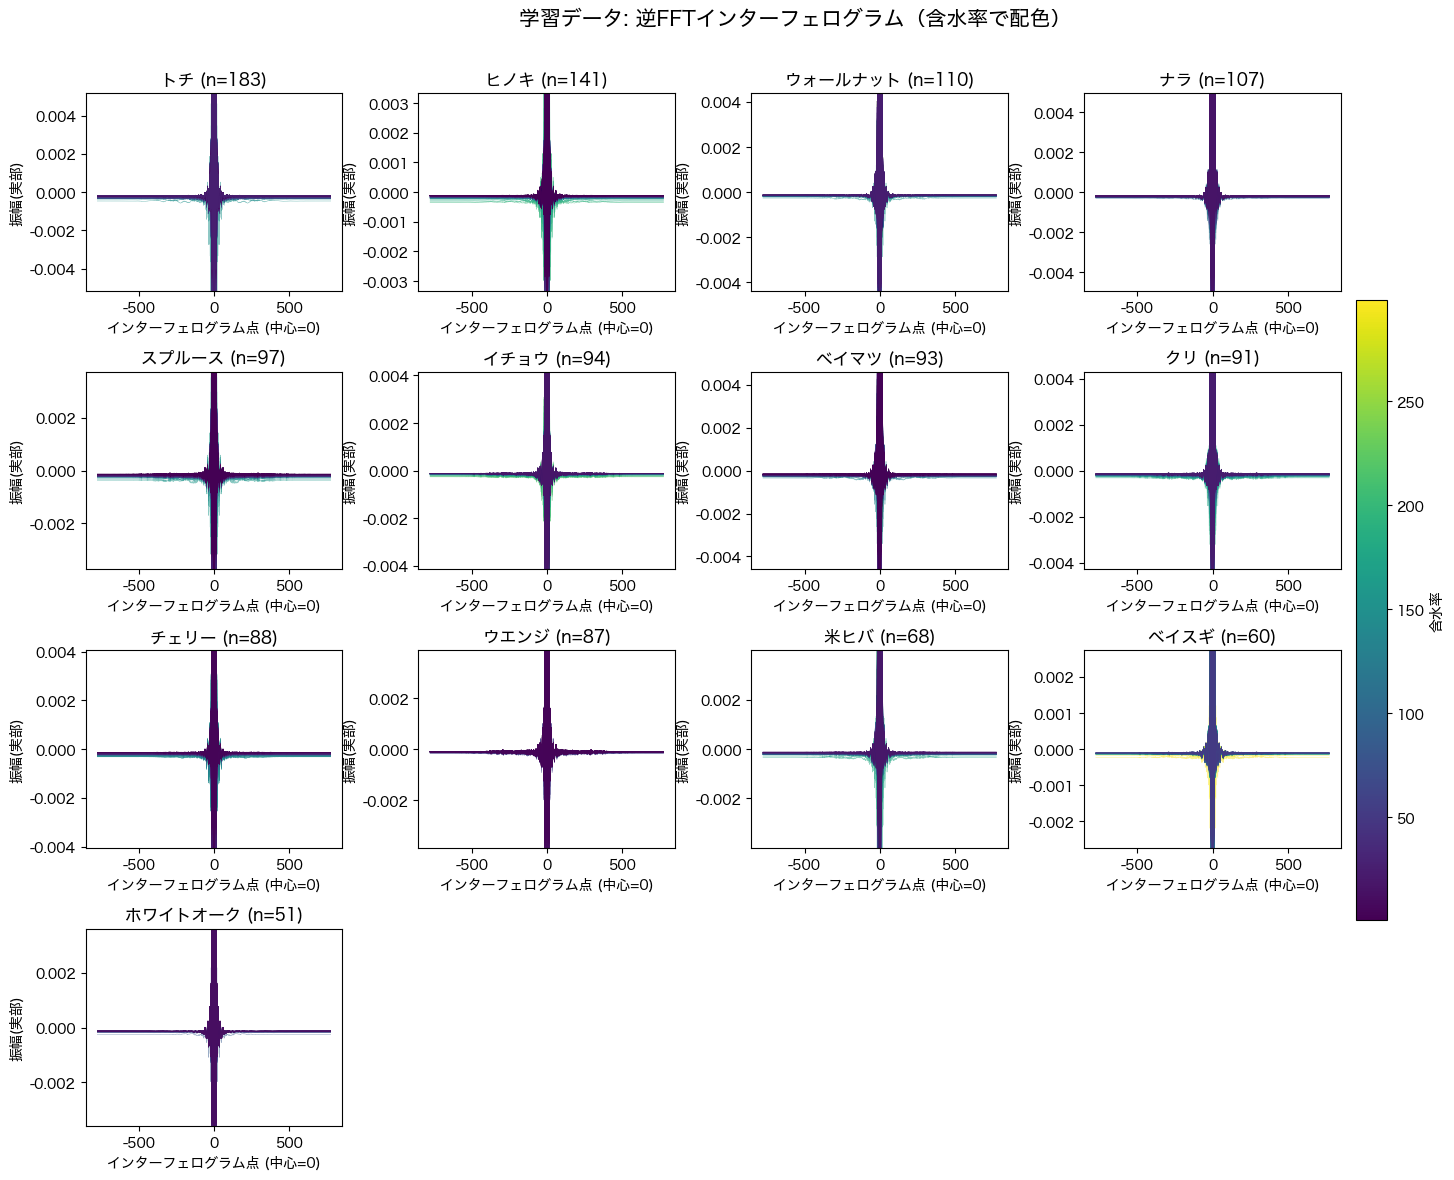

In [4]:
plot_by_species(train, train_ifg, '学習データ: 逆FFTインターフェログラム（含水率で配色）',
                color_col='含水率', ncols=4)

## テストデータ（樹種ごと）

テストには含水率（目的変数）が無いため単色で表示。

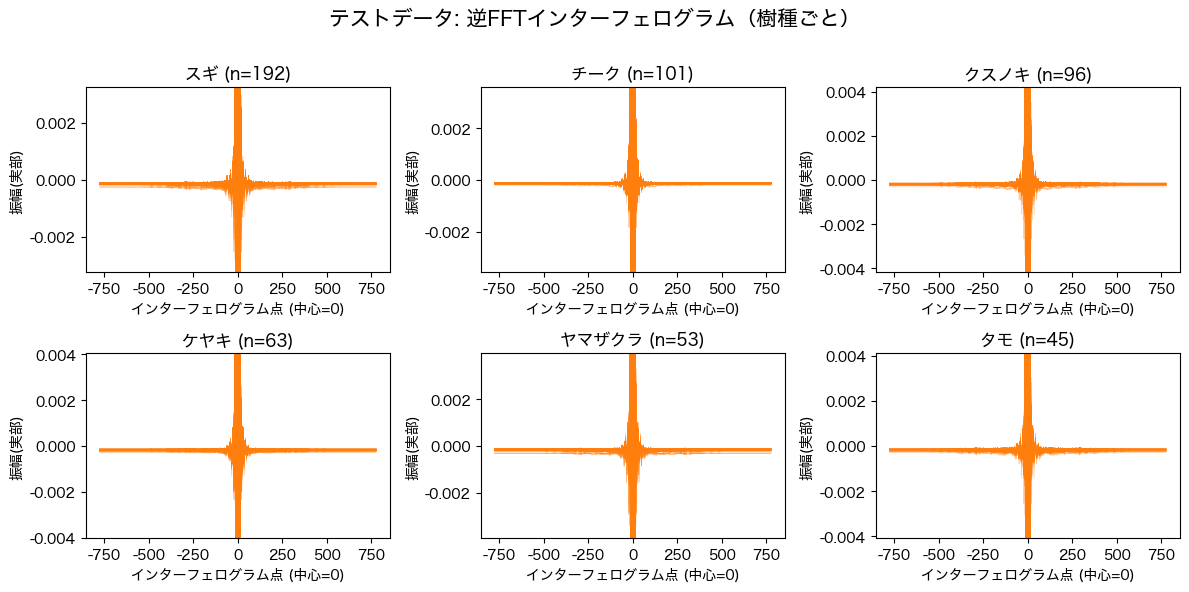

In [5]:
plot_by_species(test, test_ifg, 'テストデータ: 逆FFTインターフェログラム（樹種ごと）',
                color_col=None, ncols=3, line_color='tab:orange')

## 逆FFT特徴によるLOSO検証

逆FFTインターフェログラムを **そのまま特徴量** として、含水率を回帰する。

- 検証: **LOSO (Leave-One-Species-Out)**、指標は **macro RMSE**（樹種等重み）
- リーク回避: `StandardScaler` は **各foldの学習側でのみfit**。バンド選択等は行わない（特徴は全点固定）。
- 実部インターフェログラムは中心対称（実入力のifftはエルミート対称）なので **片側のみ** を特徴に使う。
- 比較: RF / Ridge / PLS と、学習側含水率平均を返す Baseline。

※ ifftは直交線形変換のため、情報量は元スペクトルと等価。これは「逆FFT表現でも検証が回るか／RFが表現差を活かせるか」の確認実験。

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error

# 逆FFT特徴（中心対称なので非負側のみ）
F = train_ifg[:, N // 2:]
y = train['含水率'].to_numpy(float)
sp = train['樹種'].to_numpy()
species = train['樹種'].value_counts().index.tolist()
print('特徴行列:', F.shape)

models = {
    'RF':    lambda: RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
    'Ridge': lambda: RidgeCV(alphas=np.logspace(-3, 3, 13)),
    'PLS':   lambda: PLSRegression(n_components=10),
}
preds = {m: np.full(len(y), np.nan) for m in list(models) + ['Baseline']}

for s in species:                       # LOSO
    te = sp == s; tr = ~te
    scaler = StandardScaler().fit(F[tr])
    Xtr, Xte = scaler.transform(F[tr]), scaler.transform(F[te])
    preds['Baseline'][te] = y[tr].mean()
    for name, make in models.items():
        preds[name][te] = np.ravel(make().fit(Xtr, y[tr]).predict(Xte))

def per_species_rmse(p):
    return np.array([np.sqrt(mean_squared_error(y[sp == s], p[sp == s])) for s in species])

res = pd.DataFrame({m: per_species_rmse(preds[m]) for m in preds}, index=species)
summary = res.mean().sort_values().rename('macro_RMSE').to_frame()
print('\n=== macro RMSE (樹種等重み) ===')
print(summary)

特徴行列: (1270, 778)



=== macro RMSE (樹種等重み) ===
          macro_RMSE
PLS        24.724486
RF         25.093035
Ridge      29.712066
Baseline   49.647408


/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_22083/1585025031.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([res[m] for m in mnames], labels=mnames, showmeans=True)


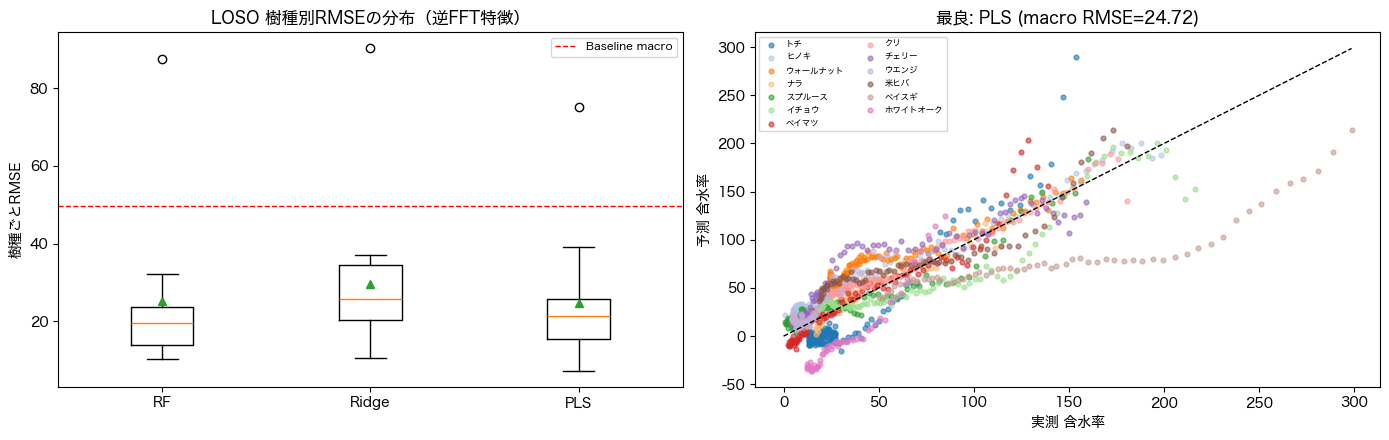

In [7]:
mnames = [m for m in preds if m != 'Baseline']
best = summary.index[0]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].boxplot([res[m] for m in mnames], labels=mnames, showmeans=True)
ax[0].axhline(res['Baseline'].mean(), color='red', ls='--', lw=1, label='Baseline macro')
ax[0].set_ylabel('樹種ごとRMSE'); ax[0].set_title('LOSO 樹種別RMSEの分布（逆FFT特徴）')
ax[0].legend(fontsize=8)

cmap = plt.get_cmap('tab20')
for i, s in enumerate(species):
    m = sp == s
    ax[1].scatter(y[m], preds[best][m], s=12, color=cmap(i % 20), alpha=.6, label=s)
lim = [min(y.min(), 0), y.max()]
ax[1].plot(lim, lim, 'k--', lw=1)
ax[1].set_xlabel('実測 含水率'); ax[1].set_ylabel('予測 含水率')
ax[1].set_title(f'最良: {best} (macro RMSE={summary.loc[best, "macro_RMSE"]:.2f})')
ax[1].legend(fontsize=6, ncol=2, loc='upper left')
plt.tight_layout(); plt.show()